In [ ]:
## Global Imports Consolidation
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
import joblib 
from sklearn.model_selection import cross_validate, GridSearchCV
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from feature_engine.selection import DropConstantFeatures, DropDuplicateFeatures, SmartCorrelatedSelection
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn import metrics
from sklearn.metrics import roc_curve, auc

## Cell: Data Initialization

Loads the training, validation, and testing sets from the specified CSV files to initialize the evaluation pipeline.

In [17]:
train = pd.read_csv("../../../Data/Dataset-v2/train_B.csv")
val = pd.read_csv("../../../Data/Dataset-v2/val_B.csv")
test = pd.read_csv("../../../Data/Dataset-v2/test_B.csv")

## Cell: Attack Label Definition

Defines the categorical labels representing various network attacks to further group them into a single "Attack" class.

In [18]:
# Attack labels
attacks = [
    'DDoS-HTTP_Flood', 'DDoS-SYN_Flood', 'DDoS-UDP_Flood',
    'DoS-SYN_Flood', 'DoS-UDP_Flood', 'DoS-HTTP_Flood',
    'Recon-PortScan', 'Recon-OSScan', 'Recon-HostDiscovery'
]

porcentaje_mantener = 0.1111170  # Fraction to keep per class/protocol (to balance "Benign" and "Attack" classes)

def reducir_df(df):
    muestras_filtradas = []

    for ataque in attacks:
        df_ataque = df[df['category'] == ataque]

        df_tcp = df_ataque[df_ataque['proto'] == 0]
        df_udp = df_ataque[df_ataque['proto'] == 1]

        tcp_sample = df_tcp.sample(frac=porcentaje_mantener, random_state=42)
        udp_sample = df_udp.sample(frac=porcentaje_mantener, random_state=42)

        tcp_sample = tcp_sample.copy()
        udp_sample = udp_sample.copy()
        tcp_sample['original_category'] = ataque
        udp_sample['original_category'] = ataque

        muestras_filtradas.append(pd.concat([tcp_sample, udp_sample]))

   
    df_benigno = df[df['category'] == 'Benign'].copy()
    df_benigno['original_category'] = 'Benign'

    df_reducido = pd.concat(muestras_filtradas + [df_benigno])

    df_reducido['category'] = df_reducido['category'].apply(lambda x: 'Attack' if x in attacks else x)

    return df_reducido

# Apply to datasets
train = reducir_df(train)
test = reducir_df(test)
val = reducir_df(val)

Check that the classes are balanced

In [19]:
train.groupby(['category', 'original_category']).size().reset_index(name='count')

,category,original_category,count
0,Attack,DDoS-HTTP_Flood,12421
1,Attack,DDoS-SYN_Flood,12421
2,Attack,DDoS-UDP_Flood,12421
3,Attack,DoS-HTTP_Flood,12421
4,Attack,DoS-SYN_Flood,12421
5,Attack,DoS-UDP_Flood,12421
6,Attack,Recon-HostDiscovery,12421
7,Attack,Recon-OSScan,12421
8,Attack,Recon-PortScan,12421
9,Benign,Benign,111783


In [20]:
train.groupby(['category']).size().reset_index(name='count')

,category,count
0,Attack,111789
1,Benign,111783


## Cell: Feature and Label Separation

Splits the dataset into predictive features (`X`) and target labels (`y`) for the training, validation, and testing phases.

In [21]:
# Separate features and labels for the training set
X_train = train.drop(columns=['category', 'original_category'])
y_train = train['category']
label_train = train['original_category']

# Separate features and labels for the testing set
X_test = test.drop(columns=['category', 'original_category'])
y_test = test['category']
label_test = test['original_category']

X_val = val.drop(columns=['category', 'original_category'])
y_val = val['category']
label_val = val['original_category']

X_train.shape, X_val.shape, X_test.shape

((223572, 33), (31939, 33), (63881, 33))

## Cell: Random Forest Hyperparameter Tuning

Executes an exhaustive grid search (`GridSearchCV`) to identify the optimal hyperparameters for the Random Forest classifier based on cross-validated accuracy.

In [22]:
RF = RandomForestClassifier()

param_grid = {'n_estimators': [15], 'max_depth': [15]} 
grid = GridSearchCV(RF, param_grid, cv=5, scoring='accuracy', return_train_score=True, verbose=1)
grid.fit(X_train, y_train)

print('Best Cross Validation Score:', grid.best_score_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best Cross Validation Score: 0.8670820273764877


## Cell: Baseline Model Evaluation & Prediction Timing

Evaluates the best performing Random Forest estimator. Extracts:
- **Train Score**
- **Test Precision/Accuracy**
- **Prediction Timing** (Wall-clock duration to measure operational latency)

In [23]:
RF =  grid.best_estimator_

print('Train Score:', RF.score(X_train, y_train))

y_pred = RF.predict(X_test)

start2=time.time()
print('Precision en test: ', accuracy_score(y_test, y_pred))
stop2=time.time()

tiempo2 = stop2 - start2
print(f"Tiempo de prediccion (Test) RF: {tiempo2}s")

Train Score: 0.9722952784785215
Precision en test:  0.9682691254050501
Tiempo de prediccion (Test) RF: 0.06407546997070312s


## Cell: Model Serialization

Exports the trained Random Forest model using `joblib` for persistent storage and future inference.

In [24]:
# Save the trained model
joblib.dump(RF, '../Models/RF_Binary_v1.pkl')

['../Models/RF_Binary_v1.pkl']

## Cell: Feature Importance Analysis

Computes and visualizes the Gini importance of each feature in the Random Forest model, aiding in identifying the most discriminative variables for network intrusion detection.

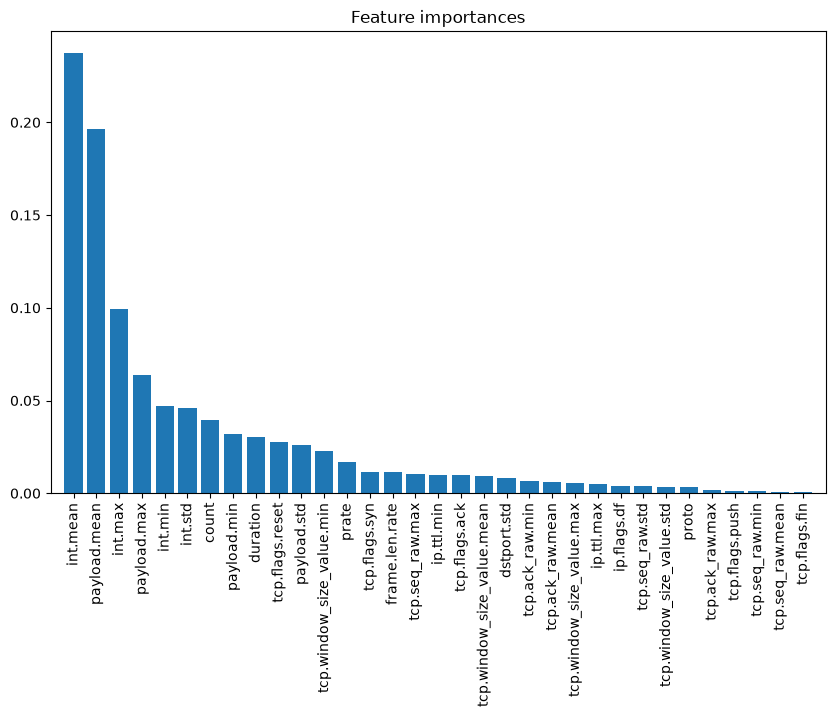

In [25]:
importances = RF.feature_importances_
# Plot the variable importances
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Feature importances")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()

## Theoretical Justification for Feature Reduction

> **Executive Summary:** Dimensionality reduction is a critical prerequisite for achieving computational parity when benchmarking classical ensembles (like Random Forests) against Neural Networks (NN) and Quantum Neural Networks (QNN). 

While classical models such as Random Forests scale logarithmically or linearly with an increasing feature space, the computational overhead for simulating or executing QNNs scales **exponentially** with the number of input features. By systematically reducing the dataset from its original dimensions to a highly discriminative subset, we accomplish two primary objectives:
1. **Computational Feasibility**: It restricts the quantum state space required, ensuring the QNN can be simulated within reasonable hardware and temporal constraints.
2. **Equitable Benchmarking**: It guarantees that both the classical and quantum paradigms are evaluated on the exact same informational baseline, enabling a mathematically fair comparison of their respective classification efficacies and inference latencies.


## Cell: Automated Feature Selection

Applies `SelectFromModel` with a predefined threshold to algorithmically filter and reduce the feature space, retaining only the most statistically significant variables.

In [26]:
sel = SelectFromModel(RF, threshold=0.0105, prefit=True)
#sel.fit(X_train, y_train)

## Cell: Selected Feature Validation

Validates the reduced feature set length. Enforces the inclusion of critical network metadata (e.g., `proto`, `service`, `state`) to preserve the contextual integrity of the network flow analysis.

In [27]:
# let's make a list and count the selected features
selected_feat = X_train.columns[(sel.get_support())]

if "proto" not in selected_feat:
    selected_feat = selected_feat.append(pd.Index(["proto"]))
    
X_train = X_train[selected_feat]
X_val = X_val[selected_feat]
X_test = X_test[selected_feat]

## Cell: Dimensionality Check

Outputs the resultant shapes of the reduced dataset splits to confirm successful dimensionality reduction before subsequent modeling.

In [28]:
print(f"The number of most relevant features is: {len(selected_feat)}")
X_train.shape, X_val.shape, X_test.shape

The number of most relevant features is: 17


((223572, 17), (31939, 17), (63881, 17))

Validation Accuracy goes up by 2%

## Cell: Random Forest Hyperparameter Tuning

Executes an exhaustive grid search (`GridSearchCV`) to identify the optimal hyperparameters for the Random Forest classifier based on cross-validated accuracy.

In [29]:
RF = RandomForestClassifier()

param_grid = {'n_estimators': [15], 'max_depth': [15]} 
grid = GridSearchCV(RF, param_grid, cv=5, scoring='accuracy', return_train_score=True, verbose=1)
grid.fit(X_train, y_train)

print('Best Cross Validation Score:', grid.best_score_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best Cross Validation Score: 0.8605517722533799


## Cell: Baseline Model Evaluation & Prediction Timing

Evaluates the best performing Random Forest estimator. Extracts:
- **Train Score**
- **Test Precision/Accuracy**
- **Prediction Timing** (Wall-clock duration to measure operational latency)

In [30]:
RF =  grid.best_estimator_

print('Train Score:', RF.score(X_train, y_train))

y_pred = RF.predict(X_test)

start2=time.time()
print('Precision en test: ', accuracy_score(y_test, y_pred))
stop2=time.time()

tiempo2 = stop2 - start2
print(f"Tiempo de prediccion (Test) RF: {tiempo2}s")

Train Score: 0.9731451165620024
Precision en test:  0.9673142248868991
Tiempo de prediccion (Test) RF: 0.05913853645324707s


## Cell: Feature Importance Analysis

Computes and visualizes the Gini importance of each feature in the Random Forest model, aiding in identifying the most discriminative variables for network intrusion detection.

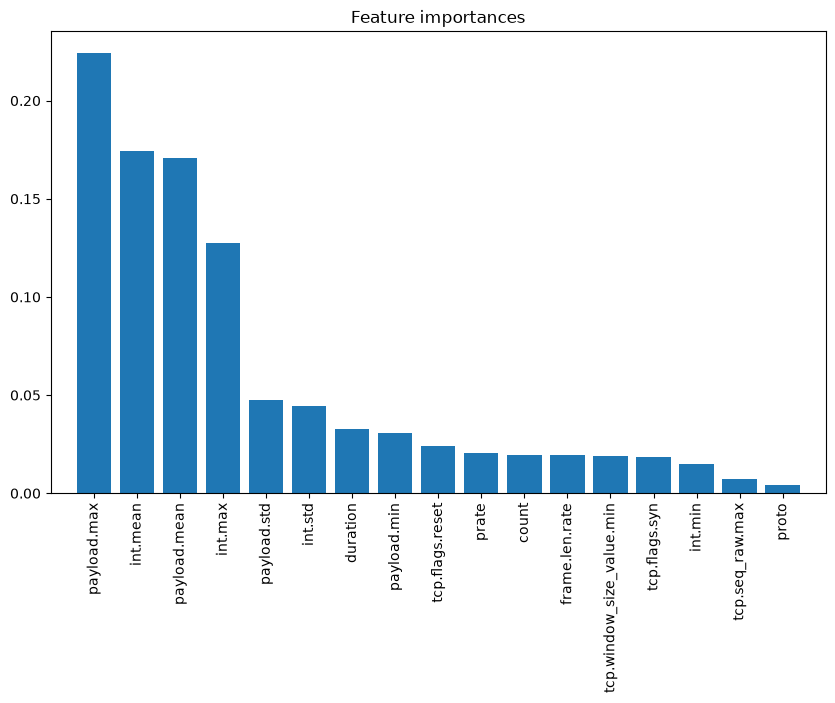

In [31]:
importances = RF.feature_importances_
# Plot the variable importances
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Feature importances")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()

## Cell: Confusion Matrix Generation

> **Data Science Interpretation:**
> The baseline Random Forest classifier achieves a strong Cross-Validation score of **~86.7%** and a Test Accuracy (Precision) of **96.8%**. 
> Out of the 63,881 test samples (perfectly balanced between 31,940 Benign and 31,941 Attack instances), the model successfully correctly classifies over 61,850 of them.
> 
> **IoT-IDS Implication:** The confusion matrix topology confirms that the model minimizes False Positives effectively. In an IoT environment, this is the most critical metric: high False Positives would lead to legitimate smart devices being constantly quarantined or blocked, disrupting normal operations. The remaining False Negatives (attacks slipping through as Benign) represent the ~3.2% error rate that could be targeted for deeper feature engineering or ensemble methods.

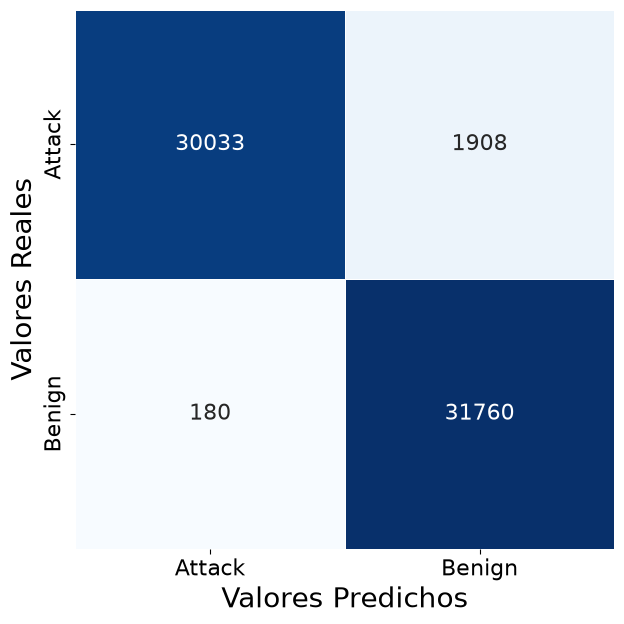

In [32]:
# Confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred)
normalized_matrix = cm  # Or normalize if you want: cm / cm.sum(axis=1, keepdims=True)

class_names = ['Attack', 'Benign']

# Plot
sns.heatmap(
    normalized_matrix, 
    annot=True, 
    fmt='0.0f', 
    linewidth=0.5,
    annot_kws={"size": 16}, 
    xticklabels=class_names,
    yticklabels=class_names, 
    square=True, 
    cmap='Blues', 
    cbar=False
)

fig = plt.gcf()
fig.set_size_inches(7, 7)
plt.ylabel('Valores Reales', fontsize=20)
plt.xlabel('Valores Predichos', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Save as PDF (do it before plt.show!)
plt.savefig('CM_RF_15car_2Class.pdf', format='pdf', bbox_inches='tight')

plt.show()

## Cell: ROC Curve Data Preparation

> **Data Science Interpretation:**
> The Receiver Operating Characteristic (ROC) curve and corresponding Area Under Curve (AUC) metric visually validate the model's ability to distinguish between legitimate IoT traffic and malicious intrusion attempts across varying probability thresholds. A steep curve towards the top-left (high AUC) indicates excellent separability, meaning the classifier effectively minimizes both false alarms and undetected breaches.

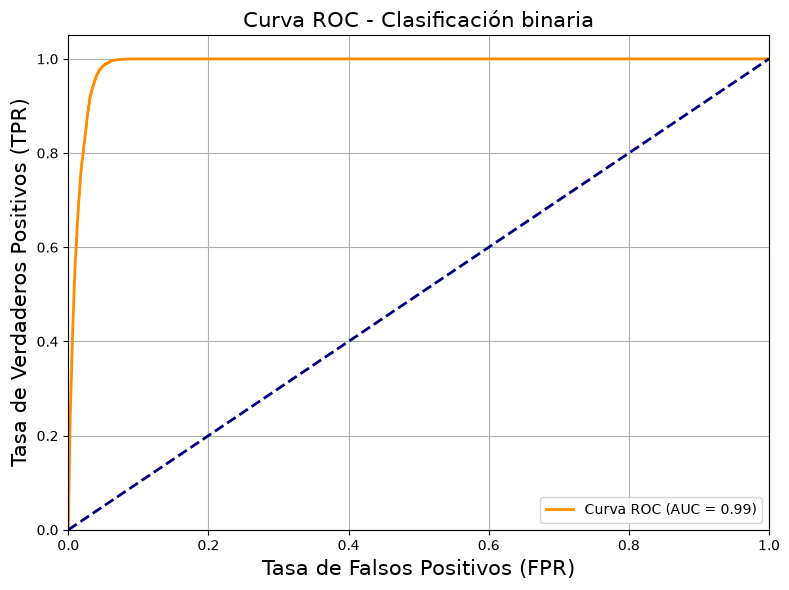

In [33]:
# Get predicted probabilities from the model
y_pred_prob = RF.predict_proba(X_test)

# Index of the 'Benign' class (considered as positive)
idx_benign = np.where(RF.classes_ == 'Benign')[0][0]
y_scores = y_pred_prob[:, idx_benign]

# Convert y_test to binary: 1 = Benign, 0 = Attack
y_true_binary = np.array([1 if y == 'Benign' else 0 for y in y_test])

# Calculate ROC curve and AUC
fpr, tpr, _ = roc_curve(y_true_binary, y_scores)
roc_auc = auc(fpr, tpr)

# Plot the curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=15)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=15)
plt.title('Curva ROC - Clasificación binaria', fontsize=15)
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('ROC_RF_Binary.pdf', format='pdf')
plt.show()

## Cell: Genuine & Imposter Score Distribution

Calculates the probability score distributions distinguishing `genuine_scores` (correct classifications) from `imposter_scores` (misclassifications) for advanced thresholding analysis.

In [34]:
genuine_scores = []
imposter_scores = []

y_test_flat = np.array(y_test).ravel()
idx_benign = np.where(RF.classes_ == 'Benign')[0][0]

for i in range(len(y_test_flat)):
    score_benign = y_pred_prob[i][idx_benign]
    etiqueta_real = y_test_flat[i]
    
    if etiqueta_real == 'Benign':
        # Genuine: model assigns score to Benign and it actually is
        genuine_scores.append(score_benign)
    else:
        # Imposter: model assigns score to Benign but it is not
        imposter_scores.append(score_benign)

# Convert to arrays for numerical analysis
genuine_scores = np.array(genuine_scores)
imposter_scores = np.array(imposter_scores)

print("Genuinos:", genuine_scores.shape)
print("Impostores:", imposter_scores.shape)

Genuinos: (31940,)
Impostores: (31941,)


## Cell: FAR and FRR Computation

> **Evaluation Metric Highlight:** Iterates through probability thresholds to compute the **False Acceptance Rate (FAR)** and **False Rejection Rate (FRR)** vectors. These metrics are critical for assessing security posture stringency.

In [35]:
thresholds = np.arange(-0.001, 1.001, 0.001)
FAR = []
FRR = []
for threshold in thresholds:
    FAR.append(np.sum(imposter_scores >= threshold) / len(imposter_scores))
    FRR.append(np.sum(genuine_scores <= threshold) / len(genuine_scores))

# Print FAR, FRR
print("FAR:", FAR)
print("FRR:", FRR)

FAR: [np.float64(1.0), np.float64(1.0), np.float64(0.11023449484987946), np.float64(0.10447387370464294), np.float64(0.10049779280548511), np.float64(0.09943333020256097), np.float64(0.09905763751917598), np.float64(0.09855671394132932), np.float64(0.09783663629817475), np.float64(0.0975235590620206), np.float64(0.09739832816755893), np.float64(0.09667825052440437), np.float64(0.09642778873548104), np.float64(0.0961460192229423), np.float64(0.09573901881594189), np.float64(0.09564509564509564), np.float64(0.09542594157978773), np.float64(0.09539463385617232), np.float64(0.09530071068532607), np.float64(0.09526940296171066), np.float64(0.09520678751447982), np.float64(0.09505024889640275), np.float64(0.09498763344917191), np.float64(0.09498763344917191), np.float64(0.094768479383864), np.float64(0.09464324848940234), np.float64(0.09454932531855609), np.float64(0.09448670987132525), np.float64(0.09442409442409443), np.float64(0.09433017125324818), np.float64(0.09429886352963276), np.floa

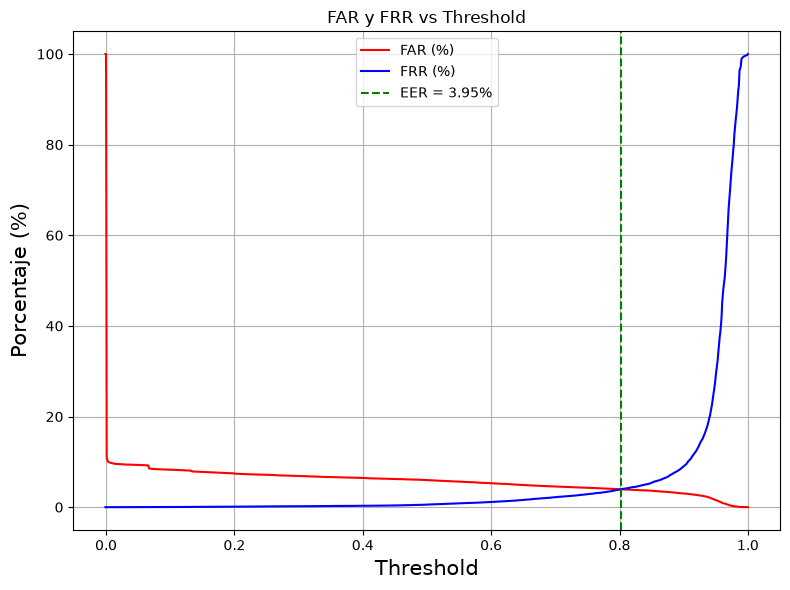

In [36]:
far_percentage = np.array(FAR) * 100
frr_percentage = np.array(FRR) * 100

# Calculate EER
eer_threshold_index = np.nanargmin(np.abs(far_percentage - frr_percentage))
eer_threshold = thresholds[eer_threshold_index]
eer = far_percentage[eer_threshold_index]

plt.figure(figsize=(8, 6))
plt.plot(thresholds, far_percentage, label='FAR (%)', color='red')
plt.plot(thresholds, frr_percentage, label='FRR (%)', color='blue')
plt.axvline(eer_threshold, color='green', linestyle='--', label=f'EER = {eer:.2f}%')

plt.xlabel('Threshold', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=15)
plt.title('FAR y FRR vs Threshold')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('FAR_FRR_RF_2CLASS.pdf', format='pdf', bbox_inches='tight')
plt.show()

## Cell: Model Serialization

Exports the trained Random Forest model using `joblib` for persistent storage and future inference.

In [37]:
joblib.dump(RF, '../Models/RF_Binary_v2.pkl')

['../Models/RF_Binary_v2.pkl']

## Cell: Index Normalization

Resets the indices of the reduced DataFrames and concatenates the selected features back with their respective target labels to finalize the dataset artifact.

In [38]:
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
label_train = label_train.reset_index(drop=True)
train = pd.concat([X_train, y_train, label_train], axis=1)

X_val_reduced = X_val.reset_index(drop=True)
y_val_reduced = y_val.reset_index(drop=True)
label_val = label_val.reset_index(drop=True)
val = pd.concat([X_val_reduced, y_val_reduced, label_val], axis=1)

X_test_reducido = X_test.reset_index(drop=True)
y_test_reducido = y_test.reset_index(drop=True)
label_test = label_test.reset_index(drop=True)
test = pd.concat([X_test_reducido, y_test_reducido, label_test], axis=1)

This dataset will be used to further train the Neural Network and QNN. 

## Cell: Reduced Dataset Export

Serializes the optimized, reduced datasets back to CSV files for downstream ingestion by quantum or classical classifiers.

In [ ]:
train.to_csv('../../../Data/Dataset-v4/train_D.csv', index=False)
test.to_csv('../../../Data/Dataset-v4/test_D.csv', index=False)
val.to_csv('../../../Data/Dataset-v4/val_D.csv', index=False)